In [1]:

# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
# Load the dataset
df = pd.read_csv("IMDB Dataset.csv")

In [3]:
# Display the first few rows of the dataset
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Data Preprocessing

In [4]:
# Dataset info
print("\n📘 Dataset Information:")
df.info()


📘 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
# Check missing values
print("\n🔍 Missing Values:")
print(df.isnull().sum())


🔍 Missing Values:
review       0
sentiment    0
dtype: int64


In [6]:
print(df.duplicated().sum())

418


In [7]:
#remove duplicates
df=df.drop_duplicates()
print(df.duplicated().sum())

0


In [8]:
# Encode sentiment labels
# you can use label encoder as well
df.replace({"sentiment": {"positive": 1, "negative": 0}}, inplace=True)

C:\Users\penix\AppData\Local\Temp\ipykernel_17292\369695931.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"sentiment": {"positive": 1, "negative": 0}}, inplace=True)


In [9]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [10]:
# Convert reviews to lowercase
df['review'] = df['review'].str.lower()
df.head(5)

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production. <br /><br />the...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically there's a family where a little boy ...,0
4,"petter mattei's ""love in the time of money"" is...",1


In [11]:
# Remove HTML tags from reviews
import re
def remove_html_tags(text):
    pattern = r'[^a-zA-Z0-9\s]'
    text = re.sub(pattern,'',text)
    return text
df['review'] = df['review'].apply(remove_html_tags)


In [12]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production br br the filmin...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


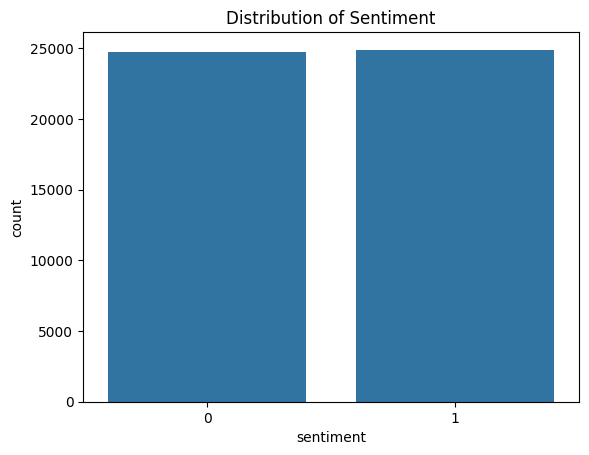

In [13]:
import seaborn as sns
sns.countplot(x='sentiment', data=df)
plt.title("Distribution of Sentiment")
plt.show()

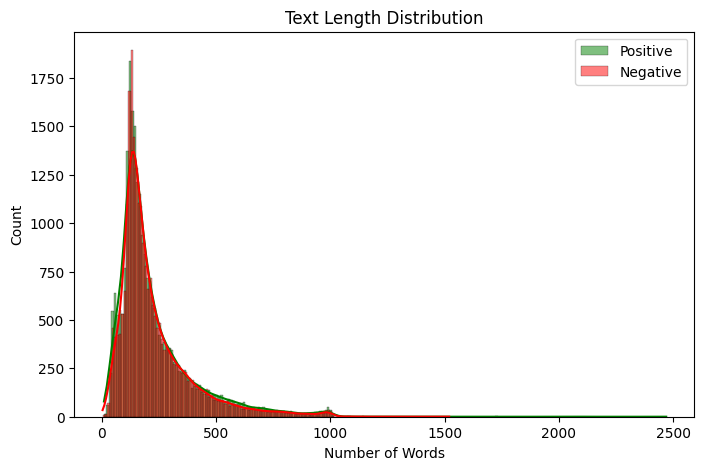

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    df[df['sentiment']==1]['review'].apply(lambda x: len(str(x).split())),
    color='green',
    label='Positive',
    kde=True
)

sns.histplot(
    df[df['sentiment']==0]['review'].apply(lambda x: len(str(x).split())),
    color='red',
    label='Negative',
    kde=True
)

plt.legend()
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

In [15]:
# Remove stopwords from reviews
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
# Intilize Stopwords
stop_words = set(stopwords.words('english'))

# Apply Stopwords
df['review'] = df['review'].apply(lambda x : ' '.join([word for word in x.split() if word not in (stop_words)]))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\penix\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
# Remove URLs from reviews
df['review'] = df['review'].str.replace('http\S+|www.\S+', '', case=False)

In [17]:
df

,review,sentiment
0,one reviewers mentioned watching 1 oz episode ...,1
1,wonderful little production br br filming tech...,1
2,thought wonderful way spend time hot summer we...,1
3,basically theres family little boy jake thinks...,0
4,petter matteis love time money visually stunni...,1
...,...,...
49995,thought movie right good job wasnt creative or...,1
49996,bad plot bad dialogue bad acting idiotic direc...,0
49997,catholic taught parochial elementary schools n...,0
49998,im going disagree previous comment side maltin...,0


In [18]:

# Split data into training and testing sets
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

Tokenize and Pad Sequences

In [19]:

# Tokenize text data
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(train_data["review"])
X_train = pad_sequences(tokenizer.texts_to_sequences(train_data["review"]), maxlen=200)
X_test = pad_sequences(tokenizer.texts_to_sequences(test_data["review"]), maxlen=200)

In [20]:
# Prepare target variables
Y_train = train_data["sentiment"]
Y_test = test_data["sentiment"]

Build and Train LSTM Model

In [21]:

# Build the LSTM model
model = Sequential()
# input_dim = tokenizer size
# output_dim = dimension of vector that you want to represent
model.add(Embedding(input_dim=5000, output_dim=128 ,  input_shape=(200,)))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation="sigmoid"))


c:\Users\penix\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 771,713 (2.94 MB)

 Trainable params: 771,713 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Compile the model
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',       
    patience=2,              
    restore_best_weights=True 
)

history = model.fit(
    X_train, Y_train,
    epochs=10,             
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 119s 235ms/step - accuracy: 0.8336 - loss: 0.3797 - val_accuracy: 0.8721 - val_loss: 0.3044
Epoch 2/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 118s 238ms/step - accuracy: 0.8934 - loss: 0.2683 - val_accuracy: 0.8813 - val_loss: 0.2953
Epoch 3/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 123s 247ms/step - accuracy: 0.9049 - loss: 0.2418 - val_accuracy: 0.8756 - val_loss: 0.3060
Epoch 4/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 112s 225ms/step - accuracy: 0.9237 - loss: 0.1982 - val_accuracy: 0.8761 - val_loss: 0.3273


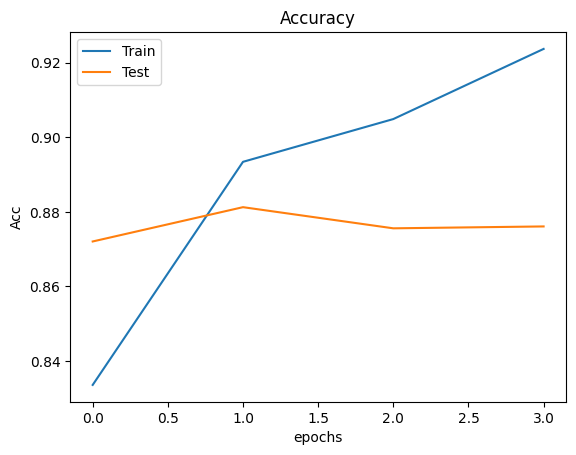

In [25]:
# Plot training and validation accuracy
plt.figure()
plt.plot(history.history["accuracy"], label = "Train")
plt.plot(history.history["val_accuracy"], label = "Test")
plt.title("Accuracy")
plt.ylabel("Acc")
plt.xlabel("epochs")
plt.legend()
plt.show()

In [26]:
# Evaluate the model on test data
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

310/310 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8812 - loss: 0.2914
Test Loss: 0.2913675904273987
Test Accuracy: 0.8812140822410583


In [27]:
# Import pickle to save models
import pickle

In [28]:
# Save tokenizer
pickle.dump(tokenizer ,open('tokenizer.pkl' , 'wb'))

In [29]:
# Save LSTM model
pickle.dump(model ,open('model.pkl' , 'wb'))